In [1]:
%load_ext autoreload
%autoreload 2
%load_ext rpy2.ipython

In [ ]:
import ibis
import ibis.selectors as s
import pandas as pd

import src
from src.load import DataLoader

ibis.options.interactive = True
r_colormap = src.r_colormap
r_out = str(src.OUT)
pd.options.display.float_format = "{:.1f}".format

In [3]:
%%R -i r_colormap -i r_out

suppressMessages(library(tidyverse))
library(ggplot2)
library(ggeffects)
library(here)
library(ggpubr)

options(scipen = 999)

cmap <- setNames(r_colormap$color, r_colormap$channel)

here() starts at /Users/lukas/git/ytpop
In addition: Warning message:
In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  library ‘/nix/store/82m40ksmhhjhcmbfc8n8vip58wbq8cxm-apple-framework-CoreFoundation-11.0.0/Library’ contains no packages


# Load Data

In [ ]:
dl = DataLoader()

videos = dl.channels().join(dl.videos(filtered=True), "channel_id").to_pandas()

sentences = (
    dl.sentences(filtered=True)
    .select(~s.cols("tokens"))
    .join(dl.popbert(filtered=False), "sentence_id")
    .to_pandas()
)

sents = sentences.groupby("video_id", observed=True).agg(
    n_sents=("video_id", "size"),
    n_elite=("elite", "sum"),
    n_pplcentr=("pplcentr", "sum"),
    avg_elite=("elite", "mean"),
    avg_pplcentr=("pplcentr", "mean"),
)

# Dataset Summary Table

In [5]:
channel_overview = (
    videos.loc[videos.video_was_live == False]
    .merge(sents, on="video_id", how="left")
    .groupby("channel", observed=True)
    .agg(
        chFollowers=("channel_follower_count", "first"),
        videos=("video_was_live", lambda x: (x == 0).sum()),
        disabledLikes=("video_likes", lambda x: x.isna().sum()),
        meanViews=("video_views", "mean"),
        medianViews=("video_views", "median"),
        meanLikes=("video_likes", "mean"),
        medianLikes=("video_likes", "median"),
        avgVideoLen=("video_duration", "mean"),
        nSentences=("n_sents", "sum"),
        # avg_comments=("video_comment_count", lambda x: x.dropna().mean()),
        first_video=("video_datetime_upload", "min"),
        latest_video=("video_datetime_upload", "max"),
    )
)

In [6]:
channel_overview

,chFollowers,videos,disabledLikes,meanViews,medianViews,meanLikes,medianLikes,avgVideoLen,nSentences,first_video,latest_video
channel,,,,,,,,,,,
AfD BT,521000,6137,0,53046.9,16341.0,4323.6,2035.0,414.0,346379,2017-12-06 13:23:54,2025-02-20 15:14:38
AfD TV,334000,1750,103,51436.1,19331.5,4282.5,2521.0,582.6,161671,2017-12-08 00:21:22,2025-02-21 15:09:57
CDU,30000,781,1,18722.9,1240.0,187.9,26.0,600.2,68446,2017-12-11 16:28:36,2025-02-22 19:13:53
CSU,6610,164,4,27944.8,941.0,46.2,24.0,455.4,12731,2017-12-14 21:19:06,2025-02-19 13:55:30
FDP,28900,671,670,18185.1,1150.0,105.0,105.0,609.3,54612,2018-01-06 16:02:32,2025-02-22 16:51:16
Greens,35400,628,7,12024.6,1273.5,172.6,32.0,617.2,50772,2018-01-27 10:45:39,2025-02-22 23:09:52
Left,117000,720,3,29833.2,3505.5,1899.6,163.0,605.9,61231,2017-12-11 14:33:45,2025-02-23 16:28:05
SPD,34500,975,2,10758.8,2341.0,193.6,82.0,638.7,86830,2017-12-07 12:17:56,2025-02-23 20:14:54


In [7]:
# number of broken transcripts

broken_transcripts = dl.broken_transcripts(filtered=True).to_pandas()
len(broken_transcripts)

80

In [8]:
# sum of durations

sum_of_seconds = videos.video_duration.sum()
print(f"Total sum of video durations: {round(sum_of_seconds / 60 / 60, 2)} hours")

Total sum of video durations: 1655.3 hours


In [9]:
# number of videos

count_videos = len(videos)
# count_videos = videos.video_id.size
print(f"Total number of valid videos: {count_videos}")

Total number of valid videos: 11826


In [10]:
# number of sentencs

count_sents = len(sentences)
print(f"Total number of valid sentences: {count_sents}")

Total number of valid sentences: 842672


In [12]:
summary_table = channel_overview.drop(["first_video", "latest_video"], axis=1).T

summary_table

channel,AfD BT,AfD TV,CDU,CSU,FDP,Greens,Left,SPD
chFollowers,521000.0,334000.0,30000.0,6610.0,28900.0,35400.0,117000.0,34500.0
videos,6137.0,1750.0,781.0,164.0,671.0,628.0,720.0,975.0
disabledLikes,0.0,103.0,1.0,4.0,670.0,7.0,3.0,2.0
meanViews,53046.9,51436.1,18722.9,27944.8,18185.1,12024.6,29833.2,10758.8
medianViews,16341.0,19331.5,1240.0,941.0,1150.0,1273.5,3505.5,2341.0
meanLikes,4323.6,4282.5,187.9,46.2,105.0,172.6,1899.6,193.6
medianLikes,2035.0,2521.0,26.0,24.0,105.0,32.0,163.0,82.0
avgVideoLen,414.0,582.6,600.2,455.4,609.3,617.2,605.9,638.7
nSentences,346379.0,161671.0,68446.0,12731.0,54612.0,50772.0,61231.0,86830.0


In [13]:
path = src.OUT / "tables/dataset_summary.csv"
path.unlink(missing_ok=True)
summary_table.to_csv(path)

# View Count Violin Plot

In [14]:
df = videos.merge(sents, on="video_id")

In [17]:
%%R -i df -w 1000 -h 600

df_plot <- df %>%
   mutate(
      likes = video_likes + 1,
      views = video_views + 1,
)

view_plot = ggplot(df_plot, aes(x=channel, y=views, fill=channel)) +
   geom_boxplot(alpha=0.6) +
   geom_violin(alpha=0.3, trim=T, scale="width") +
   scale_y_continuous(trans=scales::log10_trans(), breaks=scales::breaks_log(n=8)) +
   scale_color_manual(values=cmap, aesthetics=c("color", "fill")) +
   theme_ggeffects(
      base_family = "serif",
      base_size = 21
   ) +
   theme(
      axis.text.x=element_text(angle=20, hjust=1),
      legend.position = "none"
   ) +
   xlab("Channel") +
   ylab("log10(ViewCount)")

like_plot = ggplot(df_plot, aes(x=channel, y=likes, fill=channel)) +
   geom_boxplot(alpha=0.6) +
   geom_violin(alpha=0.3, trim=T, scale="width") +
   scale_y_continuous(trans=scales::log10_trans(), breaks=scales::breaks_log(n=8)) +
   scale_color_manual(values=cmap, aesthetics=c("color", "fill")) +
   theme_ggeffects(
      base_family = "serif",
      base_size = 21
   ) +
   theme(
      axis.text.x=element_text(angle=20, hjust=1),
      legend.position = "none"
   ) +
   xlab("Channel") +
   ylab("log10(LikeCount)")


ggarrange(view_plot, like_plot, ncol=2)

p <- here(r_out, "/figures/view_count.svg")
if (file.exists(p)) file.remove(p)
ggsave(p)

Saving 13.9 x 8.33 in image


In addition: Warning messages:
1: Removed 790 rows containing non-finite outside the scale range
(`stat_boxplot()`). 
2: Removed 790 rows containing non-finite outside the scale range
(`stat_ydensity()`). 
3: Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes. 


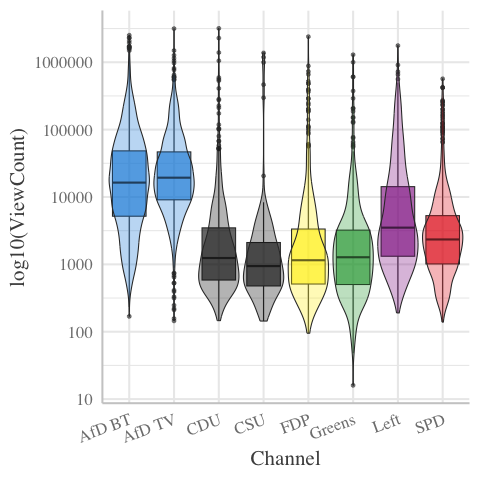

In [18]:
%%R

view_plot

# Populism Amount Plot

In [92]:
%%R -i df -w 1000 -h 600

df_plot <- df %>%
   mutate(
      elite = (n_elite / n_sents * 100) + 1,
      pplcentr = (n_pplcentr / n_sents * 100) + 1,
)

elite_plot = ggplot(df_plot, aes(x=channel, y=elite, fill=channel)) +
   geom_boxplot(alpha=0.6, outliers=F, coef=0.5) +
   scale_color_manual(values=cmap, aesthetics=c("color", "fill")) +
   theme_ggeffects(
      base_family = "serif",
      base_size = 22
   ) +
   theme(
      axis.text.x=element_text(angle=20, hjust=1),
      legend.position = "none"
   ) +
   xlab("Channel") +
   ylab("% Anti-Elitism")

pplcentr_plot = ggplot(df_plot, aes(x=channel, y=pplcentr, fill=channel)) +
   geom_boxplot(alpha=0.6, outliers=F, coef=0.5) +
   scale_color_manual(values=cmap, aesthetics=c("color", "fill")) +
   theme_ggeffects(
      base_family = "serif",
      base_size = 22
   ) +
   theme(
      axis.text.x=element_text(angle=20, hjust=1),
      legend.position = "none"
   ) +
   xlab("Channel") +
   ylab("% People-Centrism")


ggarrange(elite_plot, pplcentr_plot, ncol=2)

p <- here(r_out, "/figures/populism_per_party.svg")
if (file.exists(p)) file.remove(p)
ggsave(p)

Saving 13.9 x 8.33 in image
